# Customer Analytics — Customer Segmentation
**Author:** Manzoor Syiemlieh  
**Date:** 2025  
**Tools:** Python, Pandas, Scikit-learn, SciPy, Matplotlib, Seaborn  

## Objective
Segment customers into distinct behavioural groups using 
hierarchical clustering, K-Means and PCA to enable targeted 
marketing and personalised customer strategies.

## Dataset
2000 customer records with 7 demographic and behavioural 
features including Age, Income, Education, Occupation, 
Sex, Marital Status and Settlement Size.

## 1. Importing Libraries 

In [1]:
import pandas as pd
import scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import pickle

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Loading and Exploring Data
Loading the segmentation dataset and creating a working copy to preserve the original data throughout the analysis. 

In [2]:
raw_data = pd.read_csv("data/segmentation_data.csv", index_col=0)
df_segmentation = raw_data.copy()

In [3]:
df_segmentation.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
ID,,,,,,,
100000001,0,0,67,2,124670,1,2
100000002,1,1,22,1,150773,1,2
100000003,0,0,49,1,89210,0,0
100000004,0,0,45,1,171565,1,1
100000005,0,0,53,1,149031,1,1


## 3. Exploratory Data Analysis
Examining the statistical distribution of all features to understand the range, central tendency and spread of customer demographics and behavioural attributes.

In [4]:
df_segmentation.describe()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [5]:
df_segmentation.corr()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Sex,1.000000,0.566511,-0.182885,0.244838,-0.195146,-0.202491,-0.300803
Marital status,0.566511,1.000000,-0.213178,0.374017,-0.073528,-0.029490,-0.097041
Age,-0.182885,-0.213178,1.000000,0.654605,0.340610,0.108388,0.119751
Education,0.244838,0.374017,0.654605,1.000000,0.233459,0.064524,0.034732
Income,-0.195146,-0.073528,0.340610,0.233459,1.000000,0.680357,0.490881
Occupation,-0.202491,-0.029490,0.108388,0.064524,0.680357,1.000000,0.571795
Settlement size,-0.300803,-0.097041,0.119751,0.034732,0.490881,0.571795,1.000000


## 4. Correlation Analysis
Visualising relationships between variables to identify multicollinearity and understand which features move together before applying clustering algorithms. 

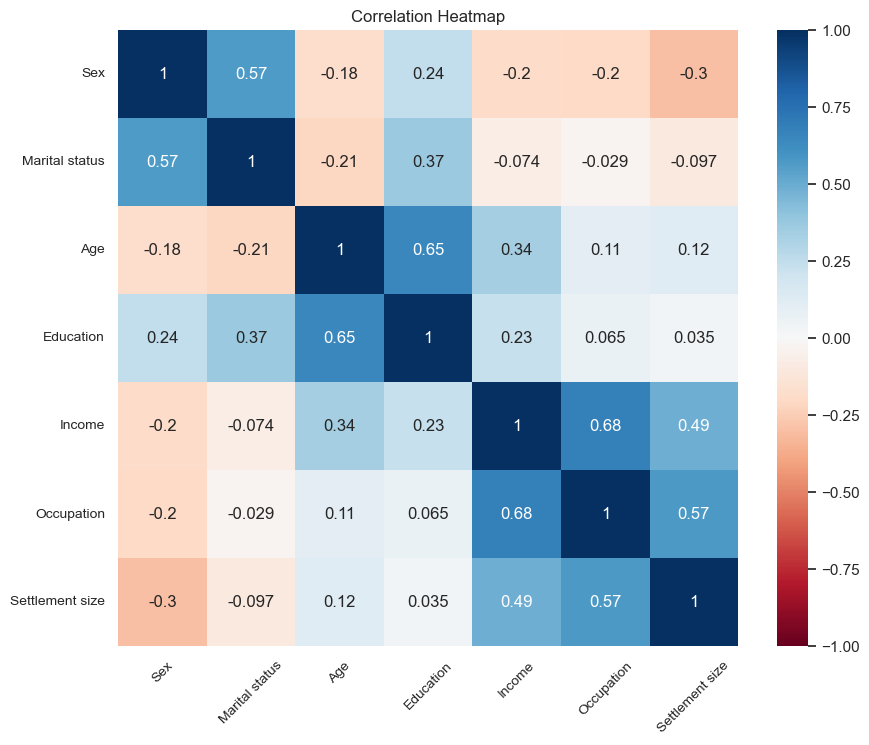

In [6]:
plt.figure(figsize=(10,8))
s = sns.heatmap(df_segmentation.corr(), annot=True, vmax=1, vmin=-1, cmap='RdBu')
s.set_yticklabels(s.get_yticklabels(), rotation=0, fontsize=10)
s.set_xticklabels(s.get_xticklabels(), rotation=45, fontsize=10)
plt.title('Correlation Heatmap')
plt.show()

Text(0.5, 1.0, 'Overall All Data Visualization')

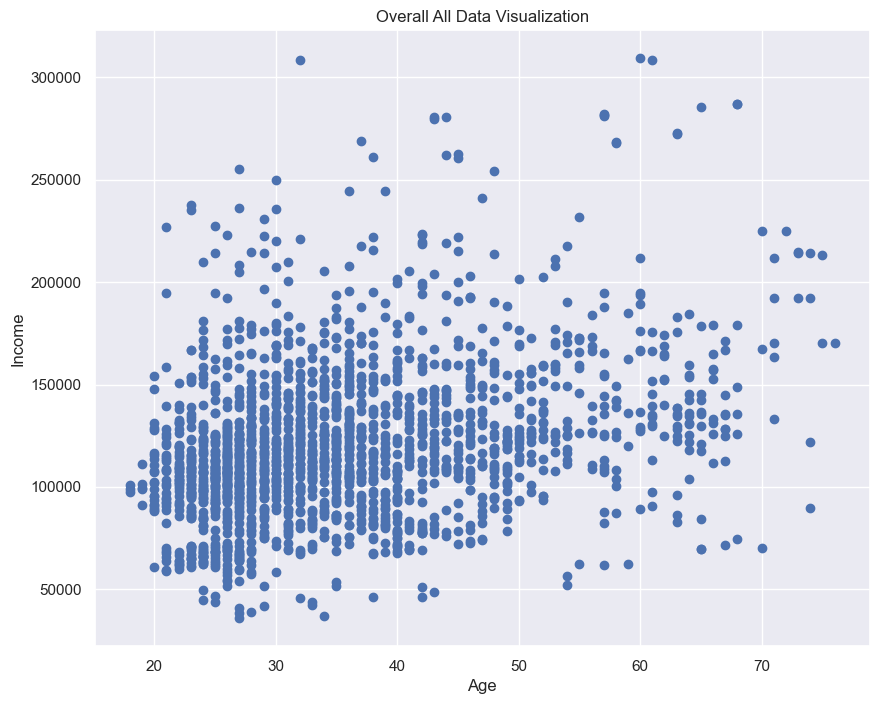

In [7]:
plt.figure(figsize=(10,8))
plt.scatter(df_segmentation['Age'], df_segmentation['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Overall All Data Visualization')

## 5. Data Standardisation
Standardising all features using StandardScaler before clustering.

**Why standardisation is essential for clustering:**  
K-Means and hierarchical clustering use distance measures. 
Without standardisation, features with larger scales (like Income) 
would dominate the distance calculation and bias the clusters 
regardless of their actual importance.

In [8]:
scaler = StandardScaler()
segmentation_std = scaler.fit_transform(df_segmentation)

## 6. Hierarchical Clustering
Using Ward linkage method to build a dendrogram and determine the optimal number of clusters before applying K-Means.

Ward linkage minimises the total within-cluster variance at each step — making it effective for identifying compact, well-separated customer segments.

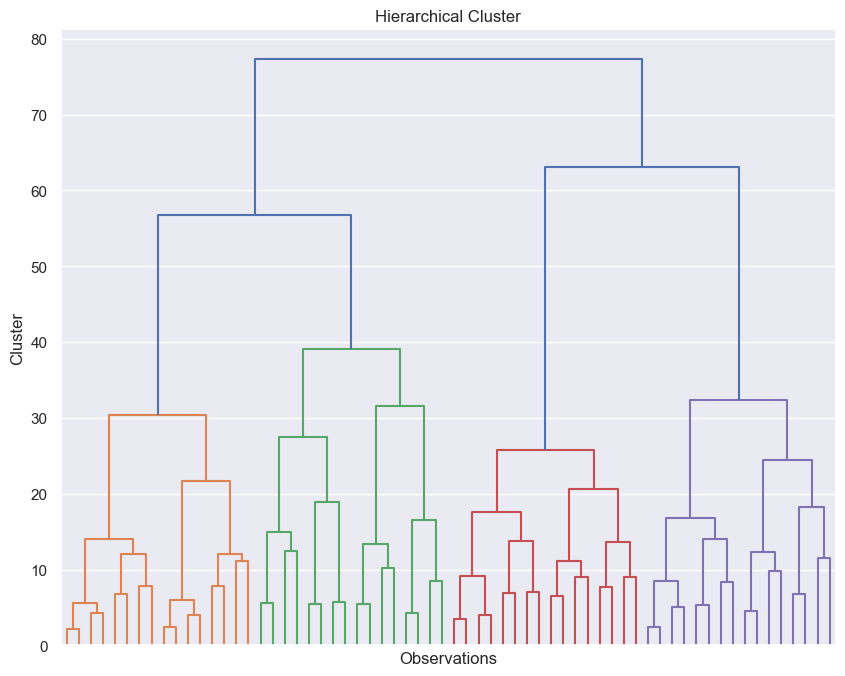

In [9]:
hier_clust = linkage(segmentation_std, method='ward')

plt.figure(figsize=(10,8))
plt.xlabel('Observations')
plt.ylabel('Cluster')
plt.title('Hierarchical Cluster')
dendrogram(hier_clust, truncate_mode='level', p=5, show_leaf_counts=False, no_labels=True)
plt.show()

## 7. Selecting Optimal Number of Clusters — Elbow Method
Running K-Means for multiple values of k and plotting WCSS to identify the elbow point where adding more clusters gives diminishing returns in variance reduction.

In [10]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(segmentation_std)
    wcss.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method')

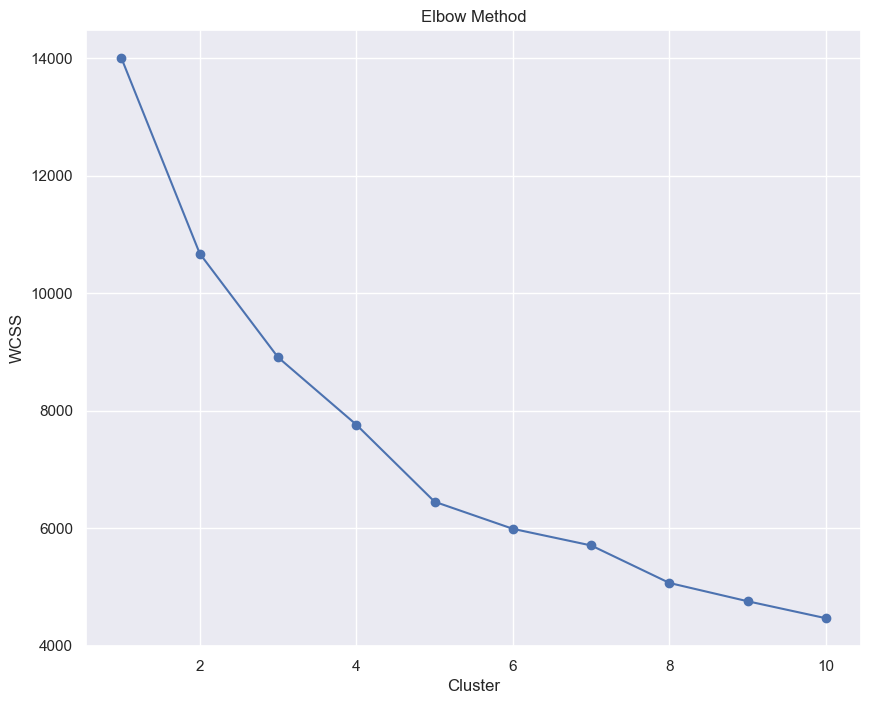

In [11]:
plt.figure(figsize=(10,8)) 
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')

## 8. K-Means Clustering
Applying K-Means with the optimal number of clusters identified from the dendrogram analysis.

K-Means assigns each customer to the nearest cluster centroid and iteratively refines assignments to minimise within-cluster sum of squares (WCSS). 

In [12]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(segmentation_std)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [13]:
df_kmeans_segm = df_segmentation.copy()
df_kmeans_segm['Segments'] = kmeans.labels_
df_kmeans_segm

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Segments
ID,,,,,,,,
100000001,0,0,67,2,124670,1,2,3
100000002,1,1,22,1,150773,1,2,2
100000003,0,0,49,1,89210,0,0,0
100000004,0,0,45,1,171565,1,1,3
100000005,0,0,53,1,149031,1,1,3
...,...,...,...,...,...,...,...,...
100001996,1,0,47,1,123525,0,0,1
100001997,1,1,27,1,117744,1,0,1
100001998,0,0,31,0,86400,0,0,0


In [14]:
df_kmeans_segm_anlysis = df_kmeans_segm.groupby('Segments').mean()
df_kmeans_segm_anlysis['N_Obs'] = df_kmeans_segm[['Segments', 'Sex']].groupby('Segments').count()
df_kmeans_segm_anlysis['Prop_Obs'] = df_kmeans_segm_anlysis['N_Obs'] / df_kmeans_segm_anlysis['N_Obs'].sum()
df_kmeans_segm_anlysis

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,N_Obs,Prop_Obs
Segments,,,,,,,,,
0,0.066543,0.000000,33.240296,0.489834,109932.785582,0.639556,0.611830,541,0.2705
1,0.868254,0.785714,32.928571,1.163492,98466.955556,0.384127,0.006349,630,0.3150
2,0.691099,0.979058,29.060209,1.104712,126838.926702,1.107330,1.324607,382,0.1910
3,0.149888,0.277405,49.192394,1.467562,160958.722595,1.364653,1.425056,447,0.2235


In [15]:
df_kmeans_segm['Labels'] = df_kmeans_segm['Segments'].map({0:'Standard',
                                                          1:'Fewer-Opportunities',
                                                          2:'Career-Focused',
                                                          3:'Well-Off'})

Text(0.5, 1.0, 'K-Means Clustering')

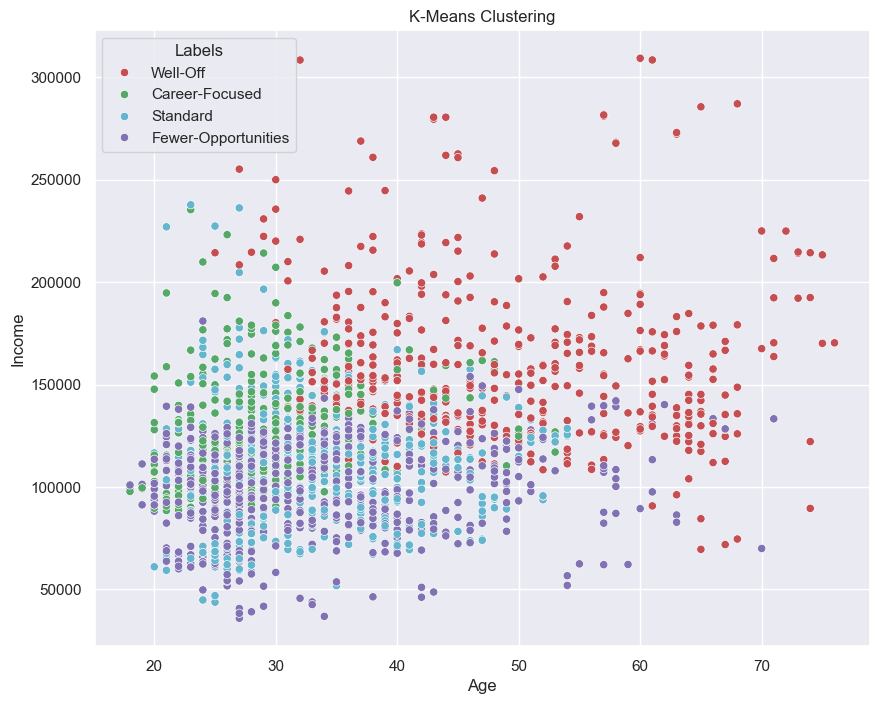

In [16]:
x_axis = df_kmeans_segm['Age']
y_axis = df_kmeans_segm['Income']

plt.figure(figsize=(10,8)) 
sns.scatterplot(x=x_axis, y=y_axis, hue=df_kmeans_segm['Labels'], palette=['r', 'g', 'c', 'm'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('K-Means Clustering')

## 9. Principal Component Analysis (PCA)
Applying PCA to reduce dimensionality before K-Means clustering.

**Why PCA before K-Means:**  
PCA removes multicollinearity between features and reduces 
noise — resulting in more distinct, stable clusters. It also 
enables 2D visualisation of high-dimensional customer segments.

In [17]:
pca = PCA()
pca.fit(segmentation_std)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [18]:
pca.explained_variance_ratio_

array([0.35696328, 0.26250923, 0.18821114, 0.0755775 , 0.05716512,
       0.03954794, 0.02002579])

Text(0.5, 1.0, 'Explained Variance Ratio')

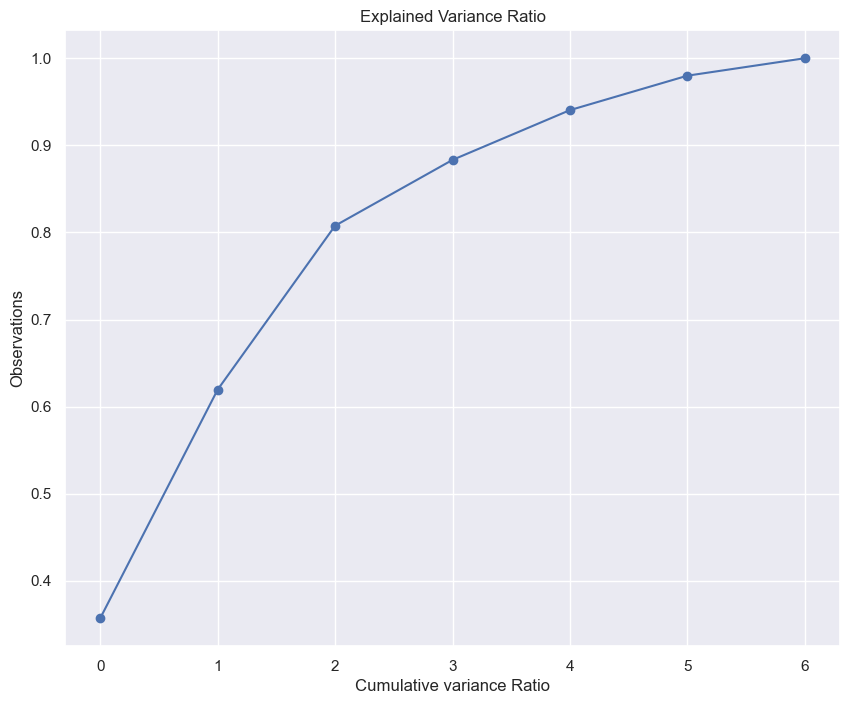

In [19]:
plt.figure(figsize=(10,8)) 
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Cumulative variance Ratio')
plt.ylabel('Observations')
plt.title('Explained Variance Ratio')

In [20]:
pca = PCA(3)
pca.fit(segmentation_std)

,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [21]:
pca.components_

array([[-0.31469524, -0.19170439,  0.32609979,  0.15684089,  0.52452463,
         0.49205868,  0.46478852],
       [ 0.45800608,  0.51263492,  0.31220793,  0.63980683,  0.12468314,
         0.01465779, -0.06963165],
       [-0.29301261, -0.44197739,  0.60954372,  0.27560461, -0.16566231,
        -0.39550539, -0.29568503]])

In [22]:
pca_comp = pd.DataFrame(pca.components_,
                       columns = df_segmentation.columns.values,
                       index = ['Component_1', 'Component_2', 'Component_3'])
pca_comp

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Component_1,-0.314695,-0.191704,0.326100,0.156841,0.524525,0.492059,0.464789
Component_2,0.458006,0.512635,0.312208,0.639807,0.124683,0.014658,-0.069632
Component_3,-0.293013,-0.441977,0.609544,0.275605,-0.165662,-0.395505,-0.295685


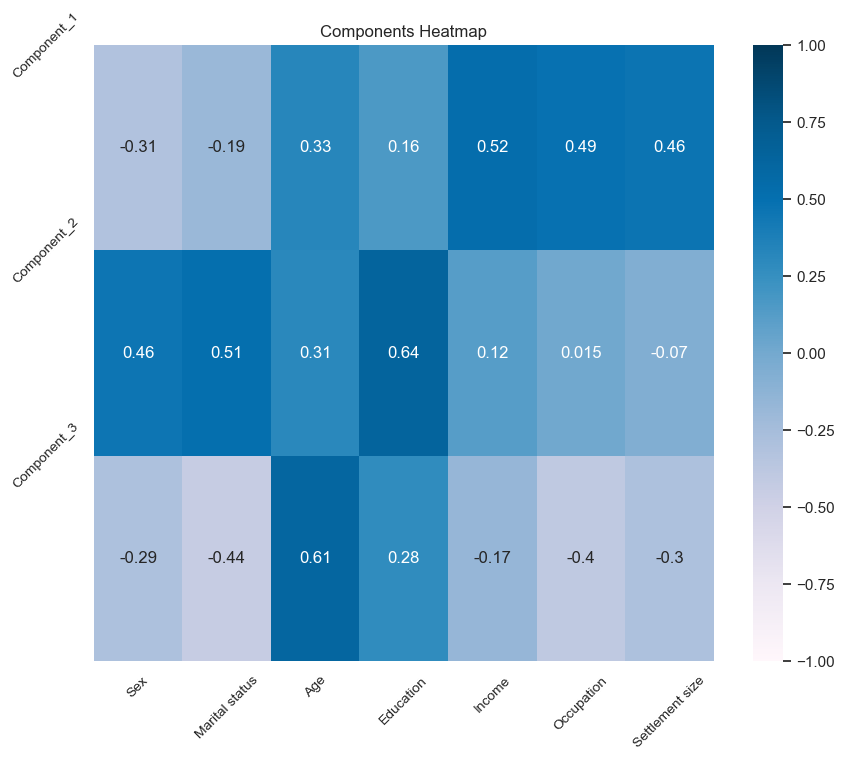

In [23]:
plt.figure(figsize=(10,8)) 
sns.heatmap(pca_comp, annot=True, vmin=-1, vmax=1, cmap='PuBu')
plt.yticks([0, 1, 2], ['Component_1', 'Component_2', 'Component_3'], rotation=45, fontsize=10)
plt.xticks(rotation=45, fontsize=10)
plt.title('Components Heatmap')
plt.show()

In [24]:
pca.transform(segmentation_std)

array([[ 2.51474593,  0.83412239,  2.1748059 ],
       [ 0.34493528,  0.59814564, -2.21160279],
       [-0.65106267, -0.68009318,  2.2804186 ],
       ...,
       [-1.45229829, -2.23593665,  0.89657125],
       [-2.24145254,  0.62710847, -0.53045631],
       [-1.86688505, -2.45467234,  0.66262172]], shape=(2000, 3))

In [25]:
scores_pca = pca.transform(segmentation_std)

In [26]:
wcss = []
for i in range(1, 11):
    kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

Text(0.5, 1.0, 'Elbow Method')

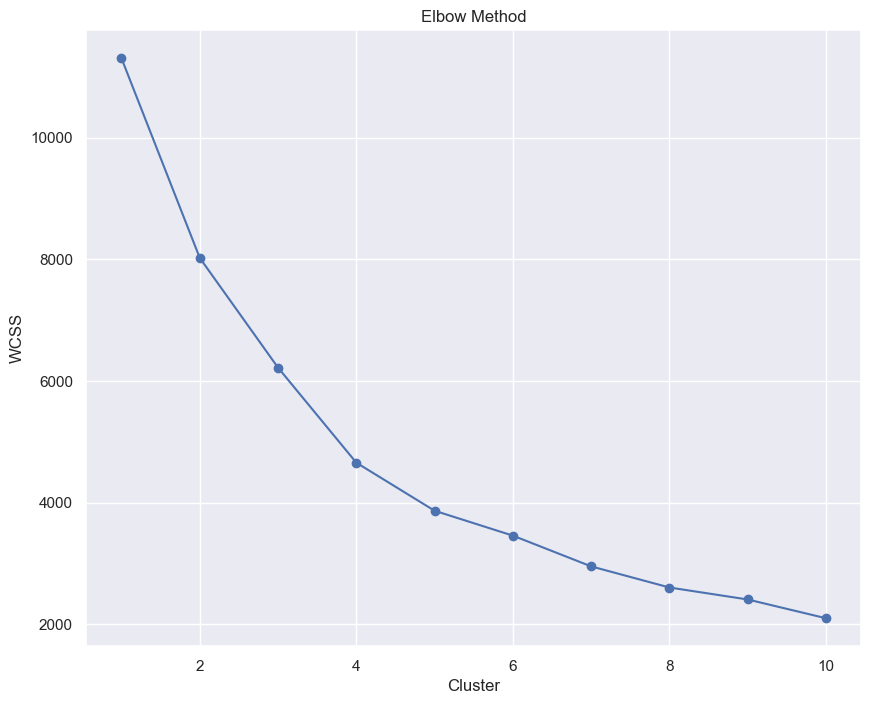

In [27]:
plt.figure(figsize=(10,8)) 
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')

## 10. K-Means Clustering on PCA Components
Applying K-Means on the PCA-transformed data for more robust and visually interpretable customer segments.

In [28]:
kmeans_pca = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_pca.fit(scores_pca)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [29]:
df_kmeans_pca_segm = pd.concat([df_segmentation.reset_index(drop=True), pd.DataFrame(scores_pca)], axis=1)
df_kmeans_pca_segm.columns.values[-3:] =['Component_1', 'Component_2', 'Component_3']
df_kmeans_pca_segm['Segments'] = kmeans_pca.labels_
df_kmeans_pca_segm

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Component_1,Component_2,Component_3,Segments
0,0,0,67,2,124670,1,2,2.514746,0.834122,2.174806,3
1,1,1,22,1,150773,1,2,0.344935,0.598146,-2.211603,2
2,0,0,49,1,89210,0,0,-0.651063,-0.680093,2.280419,1
3,0,0,45,1,171565,1,1,1.714316,-0.579927,0.730731,0
4,0,0,53,1,149031,1,1,1.626745,-0.440496,1.244909,0
...,...,...,...,...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0,-0.866034,0.298330,1.438958,1
1996,1,1,27,1,117744,1,0,-1.114957,0.794727,-1.079871,2
1997,0,0,31,0,86400,0,0,-1.452298,-2.235937,0.896571,1
1998,1,1,24,1,97968,0,0,-2.241453,0.627108,-0.530456,1


## 11. Segment Profiling and Analysis
Analysing the characteristics of each customer segment to understand what defines each group and what marketing or pricing strategies are most appropriate for each segment.

In [30]:
df_kmeans_pca_segm_analysis = df_kmeans_pca_segm.groupby('Segments').mean()
df_kmeans_pca_segm_analysis['N_Obs'] = df_kmeans_pca_segm[['Segments', 'Sex']].groupby('Segments').count()
df_kmeans_pca_segm_analysis['Prop_Obs'] = df_kmeans_pca_segm_analysis['N_Obs'] / df_kmeans_pca_segm_analysis['N_Obs'].sum()
df_kmeans_pca_segm_analysis

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Component_1,Component_2,Component_3,N_Obs,Prop_Obs
Segments,,,,,,,,,,,,
0,0.001661,0.041528,36.674419,0.684385,138482.186047,1.200997,1.255814,1.228891,-1.220013,0.041063,602,0.301
1,0.627869,0.454098,33.473770,0.944262,88824.154098,0.078689,0.009836,-1.607567,-0.110732,0.625678,610,0.305
2,0.762357,0.973384,27.889734,1.007605,119503.418251,1.055133,0.813688,-0.395592,0.518043,-1.204763,526,0.263
3,0.492366,0.683206,55.919847,2.129771,158400.877863,1.125954,1.099237,1.713376,2.021006,0.867641,262,0.131


In [31]:
df_kmeans_pca_segm['Labels'] = df_kmeans_pca_segm['Segments'].map({0:'Career-Focused',
                                                                  1:'Fewer-Opportunities',
                                                                  2:'Standard',
                                                                  3:'Well-Off'})

Text(0.5, 1.0, 'K-Means Clustering')

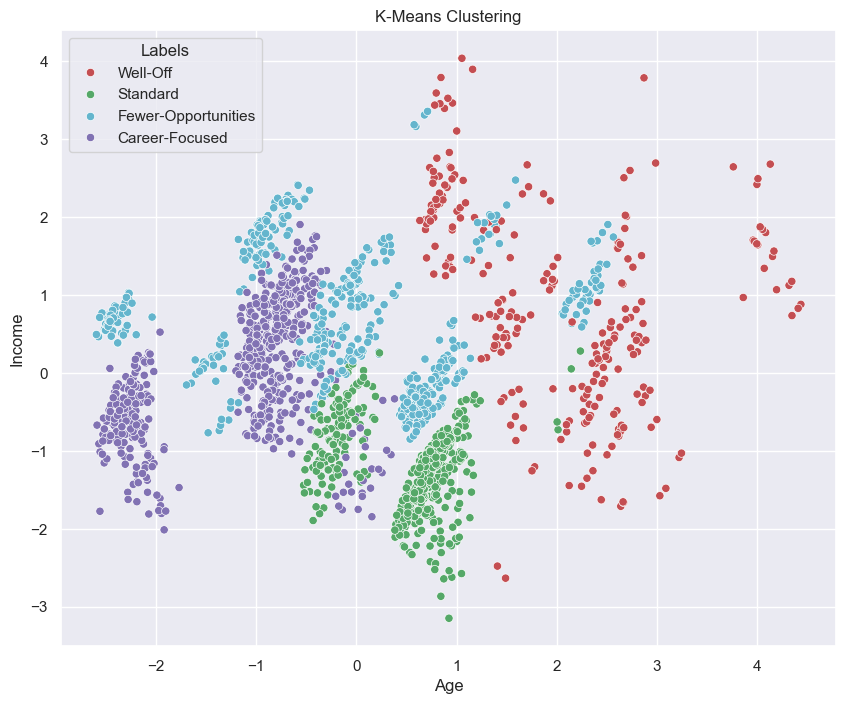

In [32]:
x_axis = df_kmeans_pca_segm['Component_2']
y_axis = df_kmeans_pca_segm['Component_3']

plt.figure(figsize=(10,8)) 
sns.scatterplot(x=x_axis, y=y_axis, hue=df_kmeans_pca_segm['Labels'], palette=['r', 'g', 'c', 'm'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('K-Means Clustering')

Text(0.5, 1.0, 'K-Means Clustering')

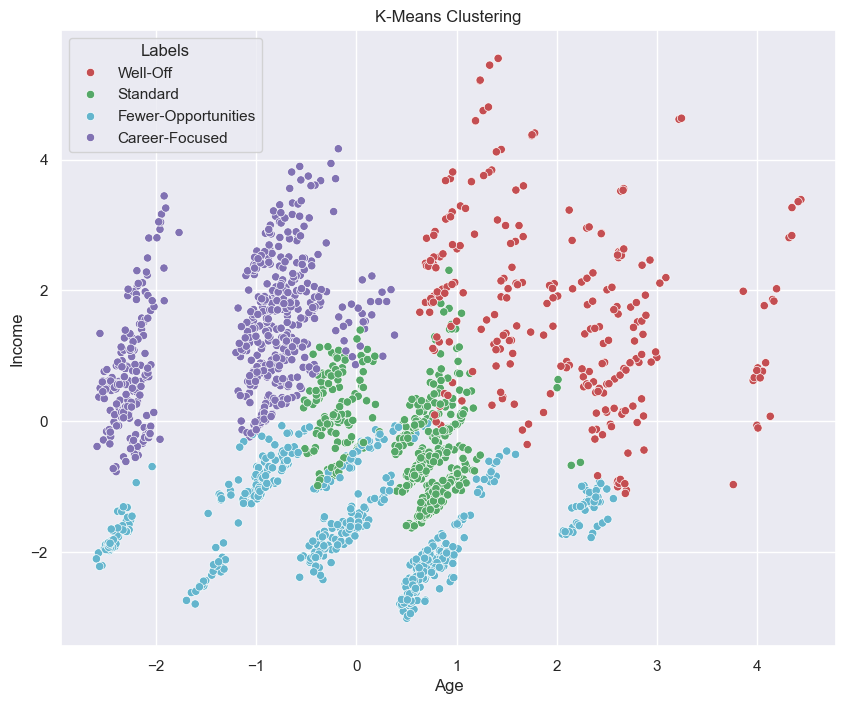

In [33]:
x_axis = df_kmeans_pca_segm['Component_2']
y_axis = df_kmeans_pca_segm['Component_1']

plt.figure(figsize=(10,8)) 
sns.scatterplot(x=x_axis, y=y_axis, hue=df_kmeans_pca_segm['Labels'], palette=['r', 'g', 'c', 'm'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('K-Means Clustering')

Text(0.5, 1.0, 'K-Means Clustering')

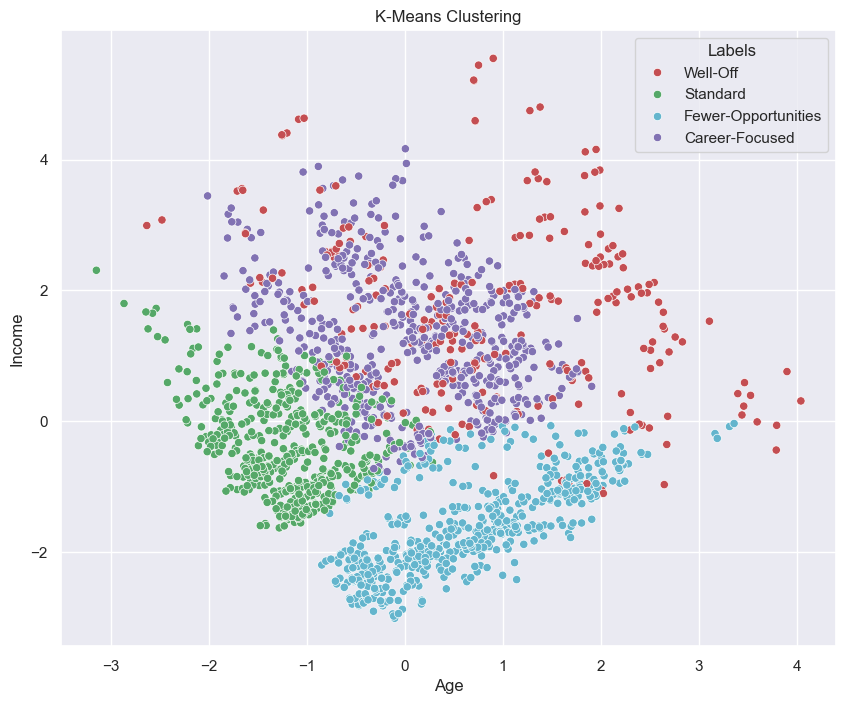

In [34]:
x_axis = df_kmeans_pca_segm['Component_3']
y_axis = df_kmeans_pca_segm['Component_1']

plt.figure(figsize=(10,8)) 
sns.scatterplot(x=x_axis, y=y_axis, hue=df_kmeans_pca_segm['Labels'], palette=['r', 'g', 'c', 'm'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('K-Means Clustering')

## 12. Saving the Model
Saving the trained scaler, PCA and K-Means models using Pickle for deployment in the Customer Analytics modelling notebook where purchase probability and price elasticity will be calculated at segment level.

In [ ]:
# Saving scaler, PCA and KMeans models for use in the Modelling notebook
# These will be loaded to ensure new data is transformed consistently

pickle.dump(scaler, open('scaler.pickle', 'wb'))
pickle.dump(pca, open('pca.pickle', 'wb'))
pickle.dump(kmeans_pca, open('kmeans_pca.pickle', 'wb'))

## 13. Summary and Key Findings

### What We Did
- Standardised 7 customer features for distance-based clustering
- Used hierarchical clustering dendrogram to identify optimal segments
- Applied K-Means and K-Means with PCA to create customer segments
- Profiled each segment by demographic and behavioural characteristics

### Key Findings
- Identified distinct customer segments with meaningfully different 
  income, age, education and occupation profiles
- PCA improved cluster separation and enabled clear 2D visualisation
- Segment profiles provide actionable basis for targeted marketing, 
  pricing strategies and customer retention programmes

### Next Steps
Results from this segmentation are used in the Modelling notebook 
to build segment-level price elasticity and purchase probability models.